# Panaroma Stichin using Homography

### Importing Libraries

In [1]:
# import the necessary packages
import numpy as np
import imutils
import cv2
import matplotlib.pyplot as plt
import glob

### Panaroma Stitcher

In [2]:
class Stitcher:

    def stitch(self, images, ratio=0.75, reprojThresh=4.0, showMatches=False):
        (imageA, imageB) = images
        (kpsA, featuresA) = self.detectAndDescribe(imageA)
        (kpsB, featuresB) = self.detectAndDescribe(imageB)

        M = self.matchKeypoints(kpsA, kpsB, featuresA, featuresB, ratio, reprojThresh)
        if M is None:
            return None

        (matches, H, status) = M
        result = self.warpPerspective(imageA, H, (imageA.shape[1] + imageB.shape[1], imageA.shape[0]))
        result[:, 0:400] = imageB


        if showMatches:
            vis = self.drawMatches(imageA, imageB, kpsA, kpsB, matches, status)
            return (result, vis)
        return result
    
    def warpPerspective(self,image, H, dsize):
        w, h = dsize
        result = np.zeros((h, w, 3), dtype=image.dtype)

        # Compute the inverse homography
        H_inv = np.linalg.inv(H)

        for y in range(h):
            for x in range(w):
                # Compute the source coordinates using inverse mapping
                pt = np.array([x, y, 1.0])
                src_pt = H_inv @ pt
                src_pt /= src_pt[2]

                src_x, src_y = int(src_pt[0]), int(src_pt[1])

                # Check if the coordinates are within bounds of the original image
                if 0 <= src_x < image.shape[1] and 0 <= src_y < image.shape[0]:
                    result[y, x] = image[src_y, src_x]
            
        return result

    def detectAndDescribe(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        descriptor = cv2.SIFT_create()
        (kps, features) = descriptor.detectAndCompute(gray, None)
        
        kps = np.float32([kp.pt for kp in kps])
        return (kps, features)
    
    # Normalize points
    def normalize_points(self,points):
        centroid = np.mean(points, axis=0)
        avg_dist = np.mean(np.linalg.norm(points - centroid, axis=1))
        scale = np.sqrt(2) / avg_dist
        T = np.array([
            [scale, 0, -scale * centroid[0]],
            [0, scale, -scale * centroid[1]],
            [0, 0, 1]
        ])
        points_homo = np.hstack([points, np.ones((points.shape[0], 1))])
        normalized_points = (T @ points_homo.T).T[:, :2]
        return normalized_points, T


    def findHomography(self,src_pts, dst_pts, reproj_thresh=4.0, max_iters=2000, confidence=0.99):
        src_pts = np.array(src_pts)
        dst_pts = np.array(dst_pts)
        assert src_pts.shape[0] == dst_pts.shape[0] and src_pts.shape[0] >= 4, "Need at least 4 point correspondences"

        num_pts = src_pts.shape[0]
        
        best_H = None
        max_inliers = 0
        src_pts_norm, T_src = self.normalize_points(src_pts)
        dst_pts_norm, T_dst = self.normalize_points(dst_pts)

        # RANSAC loop
        for _ in range(max_iters):
            # Randomly sample 4 points
            idx = np.random.choice(num_pts, 4, replace=False)
            src_sample = src_pts_norm[idx]
            dst_sample = dst_pts_norm[idx]

            # Compute homography using DLT
            A = []
            for (src, dst) in zip(src_sample, dst_sample):
                x, y = src
                u, v = dst
                A.append([-x, -y, -1, 0, 0, 0, u * x, u * y, u])
                A.append([0, 0, 0, -x, -y, -1, v * x, v * y, v])
            A = np.array(A)
            _, _, V = np.linalg.svd(A)
            H_norm = V[-1].reshape((3, 3))

            # Denormalize the homography
            H = np.linalg.inv(T_dst) @ H_norm @ T_src

            # Compute inliers
            src_pts_homo = np.hstack([src_pts, np.ones((num_pts, 1))])
            projected_pts = (H @ src_pts_homo.T).T
            epsilon = 1e-8  # Small value to avoid division by zer

            projected_pts = projected_pts[:, :2] / (projected_pts[:, 2:3] + epsilon)
            errors = np.linalg.norm(projected_pts - dst_pts, axis=1)
            inliers = errors < reproj_thresh
            num_inliers = np.sum(inliers)

            # Update best homography
            if num_inliers > max_inliers:
                max_inliers = num_inliers
                best_H = H

            # Stop early if high confidence achieved
            if max_inliers / num_pts >= confidence:
                break

        return best_H, inliers



    def matchKeypoints(self, kpsA, kpsB, featuresA, featuresB, ratio, reprojThresh):
        matcher = cv2.BFMatcher()
        rawMatches = matcher.knnMatch(featuresA, featuresB, 2)
        matches = []

        for m in rawMatches:
            if len(m) == 2 and m[0].distance < m[1].distance * ratio:
                matches.append((m[0].trainIdx, m[0].queryIdx))

        if len(matches) > 4:
            ptsA = np.float32([kpsA[i] for (_, i) in matches])
            ptsB = np.float32([kpsB[i] for (i, _) in matches])
            (H, status) =self.findHomography(ptsA, ptsB)
            return (matches, H, status)
        return None
    
    

    def drawMatches(self, imageA, imageB, kpsA, kpsB, matches, status):
        (hA, wA) = imageA.shape[:2]
        (hB, wB) = imageB.shape[:2]
        vis = np.zeros((max(hA, hB), wA + wB, 3), dtype="uint8")
        vis[0:hA, 0:wA] = imageA
        vis[0:hB, wA:] = imageB

        for ((trainIdx, queryIdx), s) in zip(matches, status):
            if s == 1:
                ptA = (int(kpsA[queryIdx][0]), int(kpsA[queryIdx][1]))
                ptB = (int(kpsB[trainIdx][0]) + wA, int(kpsB[trainIdx][1]))
                cv2.line(vis, ptA, ptB, (0, 255, 0), 1)
        return vis


### Image Dataset

Location 1


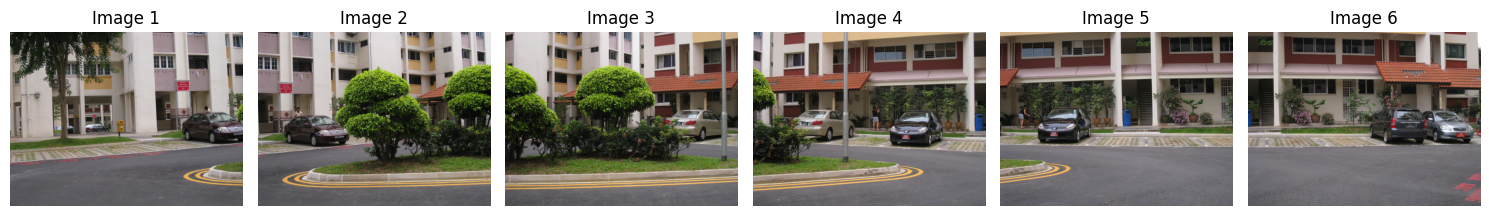

Location 2


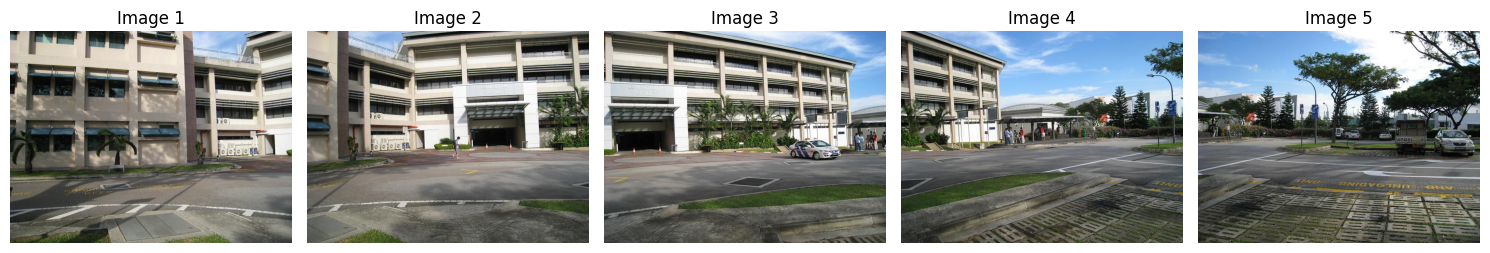

Location 3


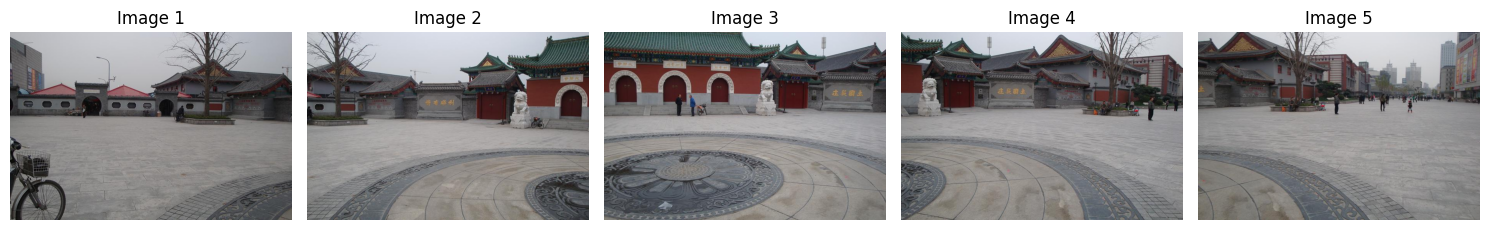

Location 4


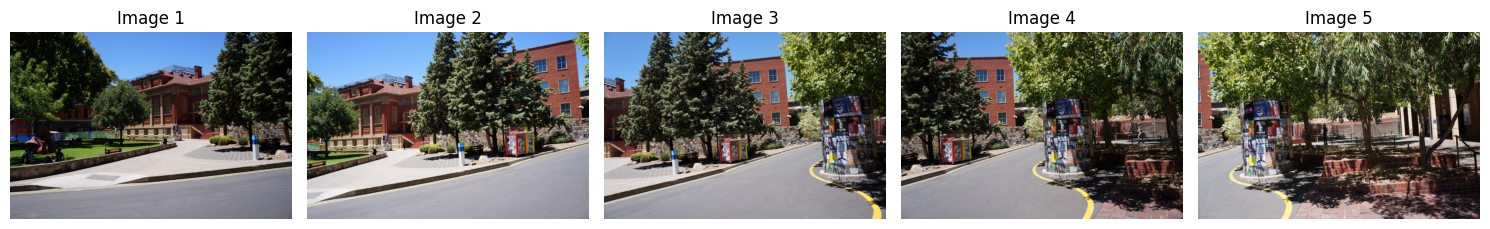

Location 5


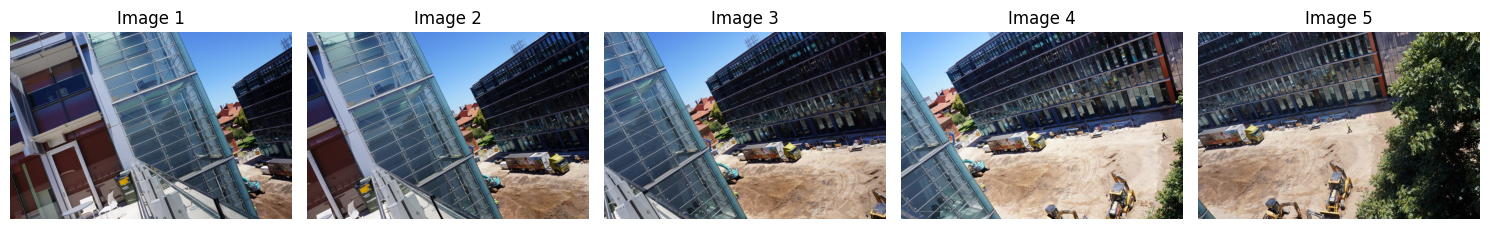

Location 6


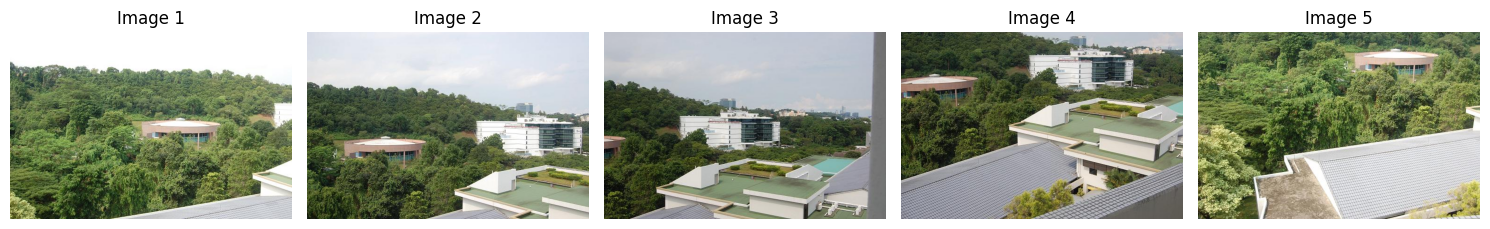

In [4]:

for i in range(6):
    print(f'Location {i+1}')
    image_paths = sorted(glob.glob(f'path'))
    fig, axes = plt.subplots(nrows=1, ncols=len(image_paths), figsize=(15, 5))  
   
    for j, img_path in enumerate(image_paths):
        img = cv2.imread(img_path)  
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
        axes[j].imshow(img)  
        axes[j].set_title(f'Image {j+1}')  
        axes[j].axis('off')  

    
    plt.tight_layout()
    plt.show() 


### Results

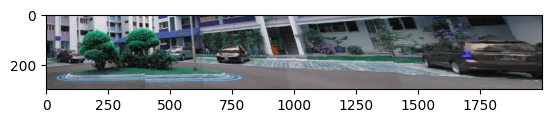

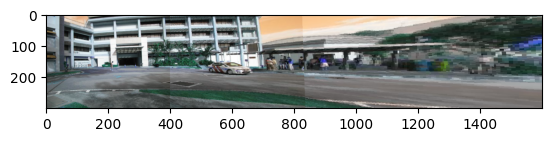

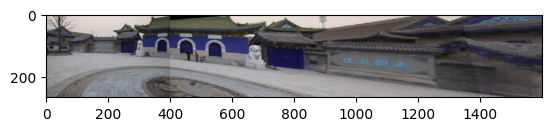

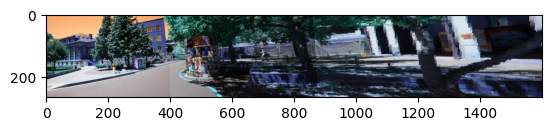

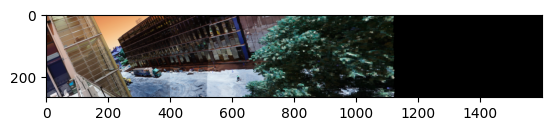

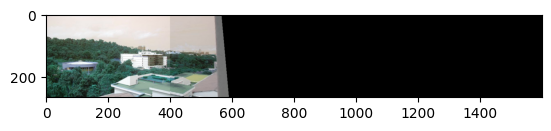

In [5]:
for i in range(6):
    image_paths = sorted(glob.glob(f'path'))  
    stitched_image = None
    stitcher = Stitcher()

    for i in range(len(image_paths)-1,0,-1 ):

        image = cv2.imread(image_paths[i])
        image = imutils.resize(image, width=400)

        if stitched_image is None:
            stitched_image = image  
        else:
            stitcher = Stitcher()
            stitched_image = stitcher.stitch([stitched_image, image])
    plt.imshow(stitched_image)
    plt.show()